<center><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/LogoEHTP.jpg" alt="drawing" width="200"/></center>

# <center> MSDE-7</center>
## Projet Module 5 : Machine Learning & Applications
## Nom : Ayat BENHAROUACHE
## Prédiction du Risque de Défaut de Remboursement de Crédit Immobilier

**Professeur :** Prof. Fadil  
**Problématique 5 :** Classification binaire - Prédire le défaut de paiement


##  Sommaire
1. État de l'Art
2. Exploration des Données (EDA)
3. Pré-processing
4. Modélisation
5. Tuning & Validation
6. Conclusion

<font>L'objectif de ce projet est de concevoir un modèle de classification capable d’identifier en amont les profils d'emprunteurs à risque, en s'appuyant sur le jeu de données Loan Default Dataset. La finalité est de fournir un outil d'aide à la décision fiable.<br>
La dataset contient 34 features :<br>
    -ID : Identifiant unique du prêt<br>
    -Gender : Sexe de l'emprunteur (Male, Female, Joint si co-emprunteur, ou Sex Not Available)<br>
    -Age : Tranche d'âge de l'emprunteur (En format catégoriel)<br>
    -Income : Revenu mensuel de l'emprunteur<br>
    -Credit_Worthiness : Évaluation de la solvabilité du client (l1 ou l2)<br>
    -Credit_type : Type de score de crédit utilisé (EXP, EQUI, CIB, CRI)<br>
    -Credit_Score : La note de crédit numérique<br>
    -Co-applicant_credit_type : Type de crédit du co-demandeur (CIB ou EXP)<br>
    -Year : L'année d'octroi du prêt<br>
    -Loan_limit : Limite du prêt<br>
    -Approv_in_adv : Montre si le prêt a fait l'objet d'une pré-approbation (nopre ou pre)<br>
    -Loan_type : Type de prêt (type1, type2, type3)<br>
    -Loan_purpose : But du prêt (p1, p2, p3, p4)<br>
    -Loan_amount : Le montant total du capital emprunté<br>
    -Term : La durée du prêt en mois<br>
    -Submission_of_application : Mode de soumission de la demande<br>
    -Rate_of_interest : Le taux d'intérêt nominal appliqué au prêt (en %)<br>
    -Interest_rate_spread : La marge d'intérêt<br>
    -Upfront_charges : Les frais de dossier ou frais initiaux payés par le client au moment du déblocage<br>
    -Neg_ammortization : Amortissement négatif (neg ou not_neg)<br>
    -Interest_only : Option "Intérêts seuls" (int_only)<br>
    -Lump_sum_payment : Paiement forfaitaire ou "prêt ballon" (not_lpsm ou lpsm)<br>
    -Property_value : La valeur estimée du bien immobilier qui sert de garantie<br>
    -Construction_type : Type de construction<br>
    -Occupancy_type : Type d'occupation du bien (pr, sec, ir )<br>
    -Secured_by : Le type de sécurité adossé au prêt (home ou land)<br>
    -Total_units : Nombre d'unités d'habitation dans le bien<br>
    -LTV (Loan-to-Value) : Le ratio Prêt/Valeur<br>
    -Dtir1 : Le ratio d'endettement (Debt-to-Income)<br>
    -Region : Région géographique où se situe le bien (south, north, central, east)<br>
    -Security_Type : Type de sûreté légale (direct ou indri)<br>
    -Status: La Variable Cible (Target)<br>
        0 : Le client rembourse normalement (Pas de défaut)<br>
        1 : Le client est en défaut de paiement<br>
    </font>

# 2. EXPLORATION DES DONNÉES (EDA)

## Objectif
Comprendre les distributions, identifier les anomalies et les relations avec la target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
#importation de la data
df=pd.read_csv("Loan_Default.csv")

In [3]:
#Affichage des 10 premiers lignes
df.head(10)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
7,24897,2019,NaN,Female,nopre,type1,p4,l1,nopc,nob/c,...,CIB,863,CIB,55-64,to_inst,86.525974,North,direct,0,42.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
9,24899,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,...,CIB,788,EXP,55-64,to_inst,63.444767,south,direct,0,30.0


In [4]:
#Affichage de la taille de la dataset
df.shape

(148670, 34)

In [5]:
#Affichage des colonnes
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [6]:
#Affichage des infos des variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [7]:
df[['loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value',
       'income', 'LTV', 'dtir1','Credit_Score']].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amount,148670.0,331117.743997,183909.310127,16500.000000,196500.00000,296500.00000,436500.000000,3.576500e+06
rate_of_interest,112231.0,4.045476,0.561391,0.000000,3.62500,3.99000,4.375000,8.000000e+00
Interest_rate_spread,112031.0,0.441656,0.513043,-3.638000,0.07600,0.39040,0.775400,3.357000e+00
Upfront_charges,109028.0,3224.996127,3251.121510,0.000000,581.49000,2596.45000,4812.500000,6.000000e+04
term,148629.0,335.136582,58.409084,96.000000,360.00000,360.00000,360.000000,3.600000e+02
property_value,133572.0,497893.465696,359935.315562,8000.000000,268000.00000,418000.00000,628000.000000,1.650800e+07
income,139520.0,6957.338876,6496.586382,0.000000,3720.00000,5760.00000,8520.000000,5.785800e+05
LTV,133572.0,72.746457,39.967603,0.967478,60.47486,75.13587,86.184211,7.831250e+03
dtir1,124549.0,37.732932,10.545435,5.000000,31.00000,39.00000,45.000000,6.100000e+01
Credit_Score,148670.0,699.789103,115.875857,500.000000,599.00000,699.00000,800.000000,9.000000e+02


### Étapes
- **Bloc A** : Analyse de la variable cible (déséquilibre)

In [8]:
#vérification de l'équilibre de la valeur cible selon la répartition du status 
print("Répartition en pourcentage :")
print(df['Status'].value_counts(normalize=True) * 100)

Répartition en pourcentage :
Status
0    75.355485
1    24.644515
Name: proportion, dtype: float64


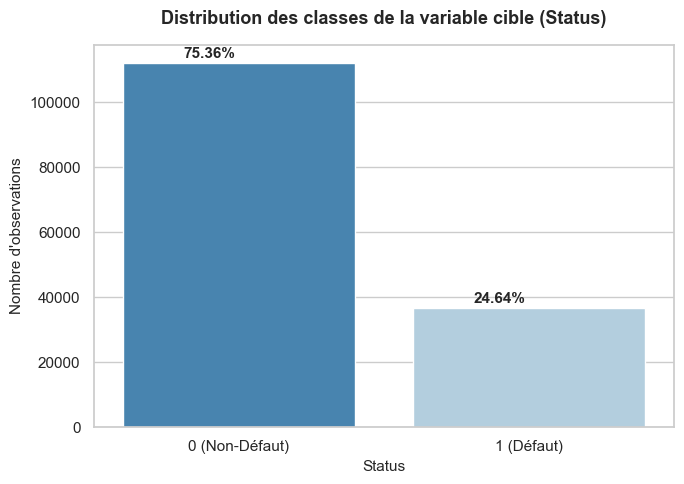

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

ax = sns.countplot(x='Status', data=df, palette='Blues_r', hue='Status', legend=False)

plt.title("Distribution des classes de la variable cible (Status)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Status", fontsize=11)
plt.ylabel("Nombre d'observations", fontsize=11)
plt.xticks(ticks=[0, 1], labels=['0 (Non-Défaut)', '1 (Défaut)'])


total = len(df['Status'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + (total * 0.01) # Petit décalage vers le haut
    ax.annotate(percentage, (x, y), fontsize=11, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

### Observation : 
La variable cible est fortement déséquilibrée : 75,36 % de Non-Défaut (classe 0) contre seulement 24,64 % de Défaut (classe 1). j'ai décidé de garder cette proportion vu le contexte de déploiement (solvabilité crédit) 

- **Bloc B** : Distributions des variables numériques (asymétries, outliers)

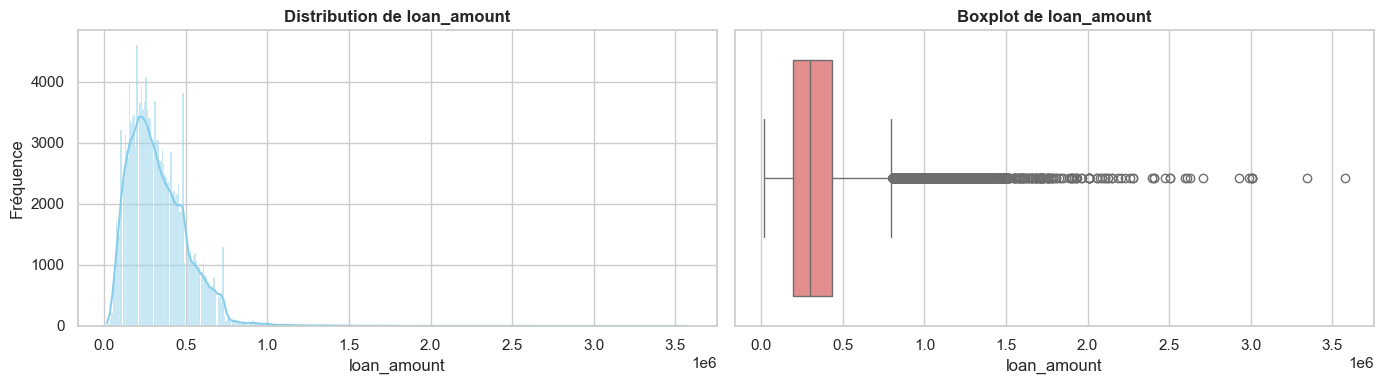

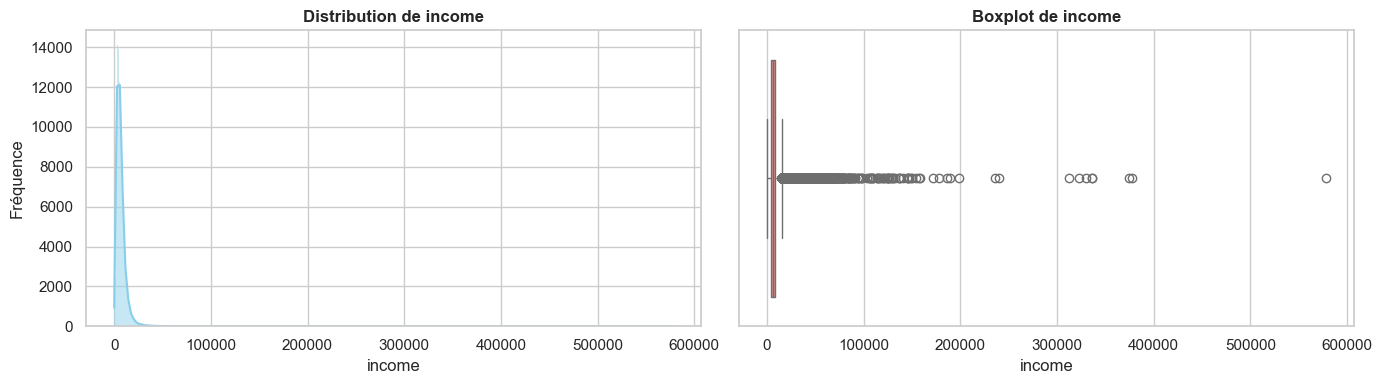

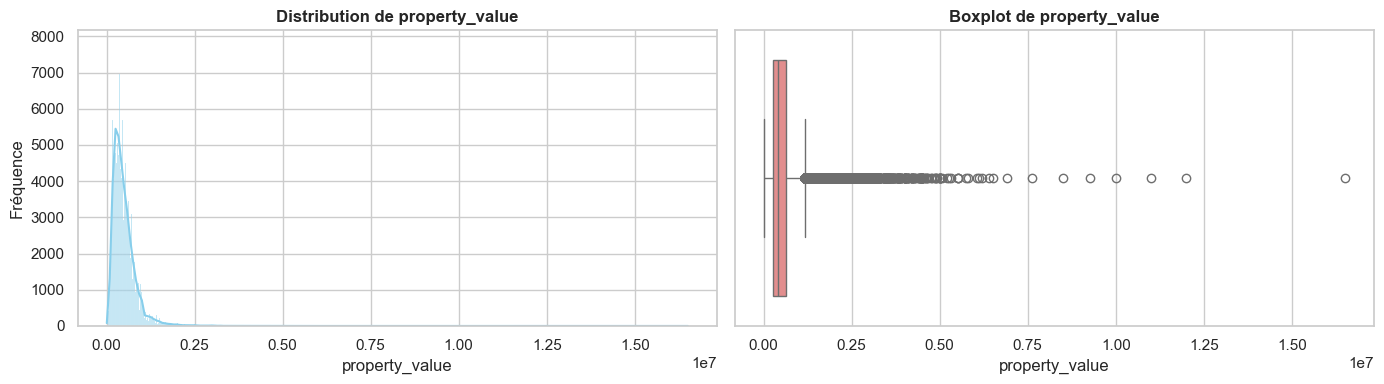

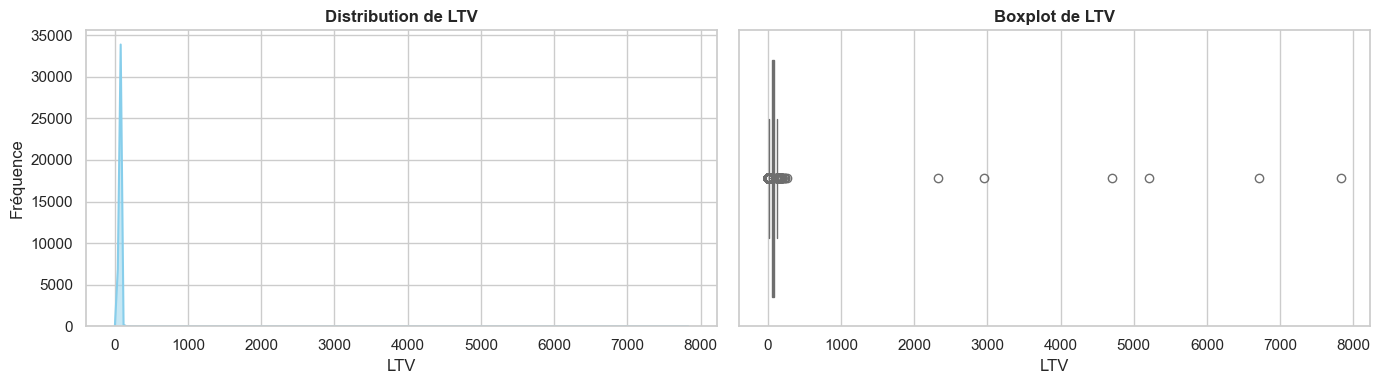

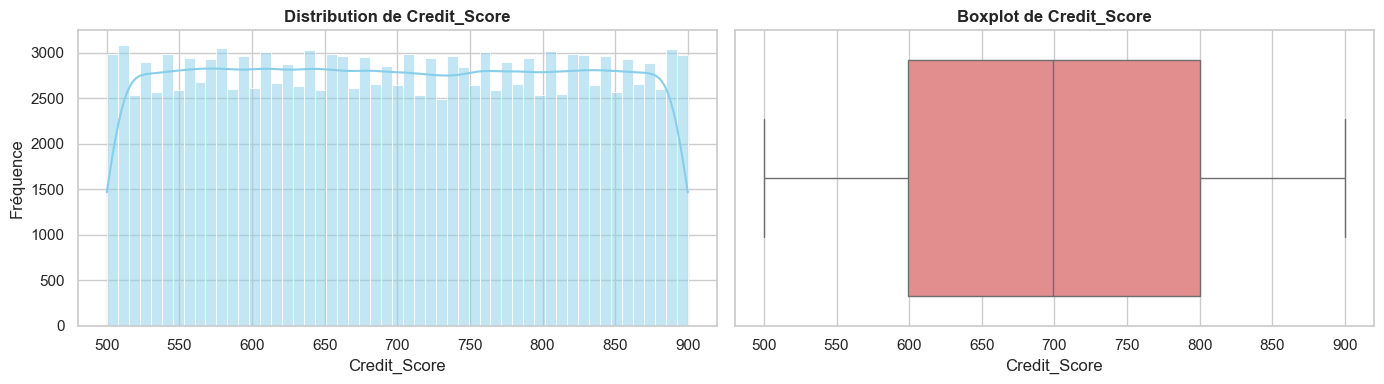

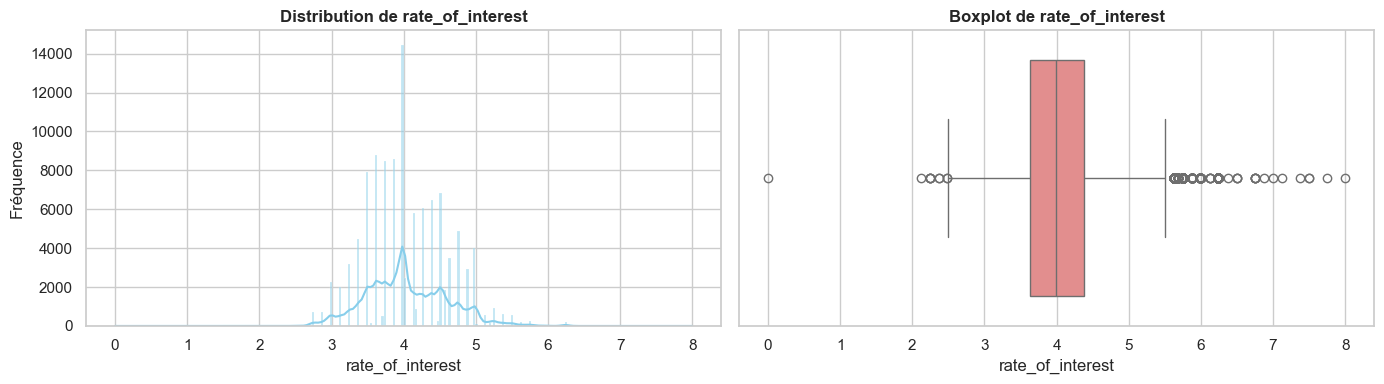

In [10]:

cols_a_tracer = ['loan_amount', 'income', 'property_value', 'LTV', 'Credit_Score', 'rate_of_interest']

# Boucle pour traiter chaque colonne
for col in cols_a_tracer:
    # Création d'une figure 
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Fréquence')
    
    # Boxplot : repérage des outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col)
        
    plt.tight_layout()
    plt.show()

In [11]:
df[df['LTV'] > 120][['LTV', 'loan_amount', 'property_value']].sort_values('LTV', ascending=False).head(20)

,LTV,loan_amount,property_value
16951,7831.250000,626500,8000.0
55286,6706.250000,536500,8000.0
47807,5206.250000,416500,8000.0
65238,4706.250000,376500,8000.0
46287,2956.250000,236500,8000.0
123343,2331.250000,186500,8000.0
43348,263.541667,126500,48000.0
30837,237.500000,66500,28000.0
27473,237.500000,66500,28000.0
136154,220.362903,546500,248000.0


### Conclusion
J'en conclus une forte asymétrie et une présence d'outliers : Les variables financières cruciales (income, loan_amount, property_value) sont fortement biaisées par des valeurs extrêmes. on remarque des anomalies de saisie, par exemple La variable LTV présente des anomalies évidentes (contient 193 valeurs aberrantes (>120%, impossibles métier), causées par des property_value anormalement faibles ). 
Afin d'éviter d'induire le modèle en erreur, Je procéderai à un nettoyage ou suppression étant donné que cette variable est un calcul mathématique de 2 variables (loan_amount et property_value)


- **Bloc C** : Corrélations entre variables

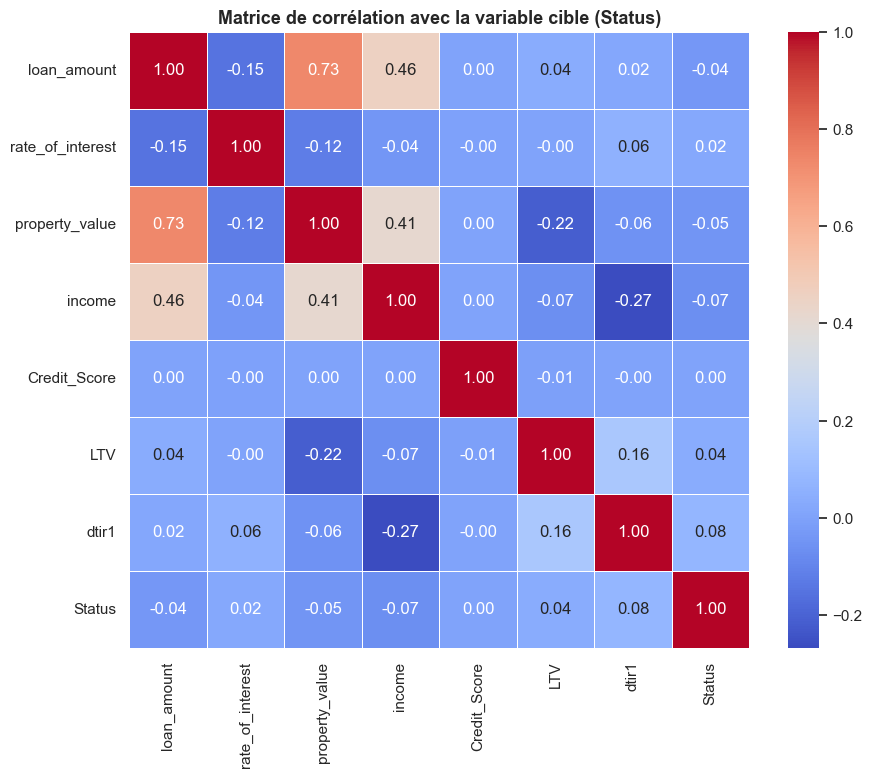

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des principales variables quantitatives avec status
num_cols = ['loan_amount', 'rate_of_interest', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1', 'Status']

# Calcul de la matrice de corrélation
corr_matrix = df[num_cols].corr()

# Affichage de la Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation avec la variable cible (Status)", fontsize=13, fontweight='bold')
plt.show()

### Conclusion
Je ne constate pas de relation linéaire : toutes les variables affichent une corrélation proche de 0 avec Status (même Credit_Score). Cela prouve que le risque de défaut ne dépend pas d'un facteur unique, mais de combinaisons complexes entre variables — ce qui oriente vers des modèles non-linéaires (arbres, Random Forest, Gradient Boosting) capables de capter ces interactions.</br>
Par contre, je constate une forte corrélation entre le montant du prêt (loan_amount) et la valeur du bien (property_value) à 0,73 : cette redondance (multicolinéarité) devra être prise en compte lors de la feature selection, où l'une des deux variables pourra être écartée.

- **Bloc D** : Comparaison numériques vs target


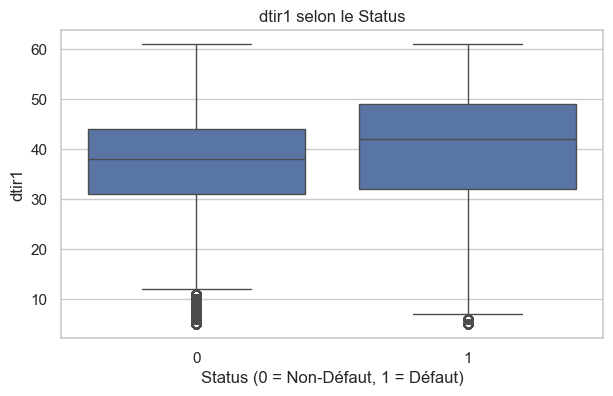

             mean  median
Status                   
0       37.369267    38.0
1       39.597324    42.0


In [12]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Status', y='dtir1')
plt.title('dtir1 selon le Status')
plt.xlabel('Status (0 = Non-Défaut, 1 = Défaut)')
plt.ylabel('dtir1')
plt.show()

print(df.groupby('Status')['dtir1'].agg(['mean', 'median']))

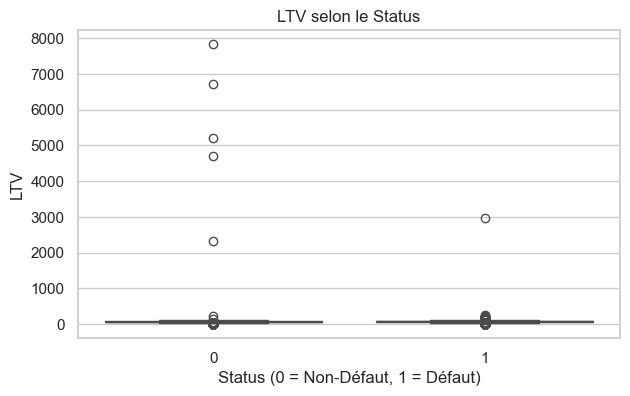

             mean     median
Status                      
0       72.064757  74.504405
1       76.291468  79.362416


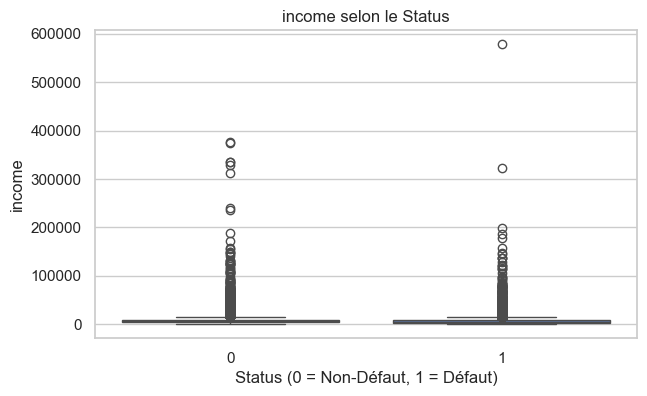

               mean  median
Status                     
0       7204.014214  6000.0
1       6231.806780  4860.0


In [13]:
for col in ['LTV', 'income']:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='Status', y=col)
    plt.title(f'{col} selon le Status')
    plt.xlabel('Status (0 = Non-Défaut, 1 = Défaut)')
    plt.ylabel(col)
    plt.show()
    print(df.groupby('Status')[col].agg(['mean', 'median']))

### Conclusion
L'analyse bivariée révèle que les clients en situation de défaut (Status = 1) affichent globalement des indicateurs de risque plus élevés, avec un taux d'endettement médian qui passe de 38 à 42 et un LTV médian de 74,5 à 79,4 — des écarts faibles mais cohérents avec la logique de risque. Les distributions confirment par ailleurs la présence de valeurs aberrantes extrêmes (LTV atteignant 8 000, revenus isolés au-delà de 500 000) dans les deux classes.

- **Bloc E** : Comparaison catégorielles vs target

Status                     0          1
Credit_Worthiness                      
l1                 75.672315  24.327685
l2                 68.226367  31.773633


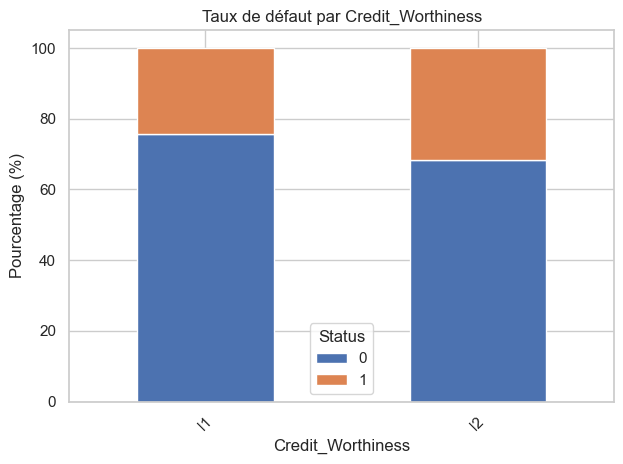

Status                          0          1
business_or_commercial                      
b/c                     65.456122  34.543878
nob/c                   76.962348  23.037652


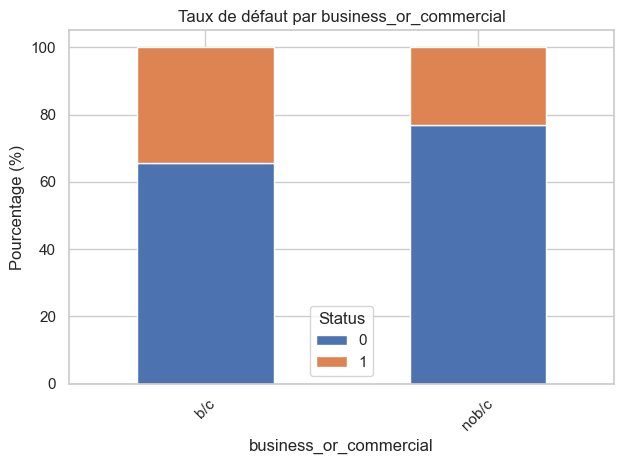

Status              0          1
Region                          
North       77.488558  22.511442
North-East  69.554656  30.445344
central     72.461768  27.538232
south       73.370720  26.629280


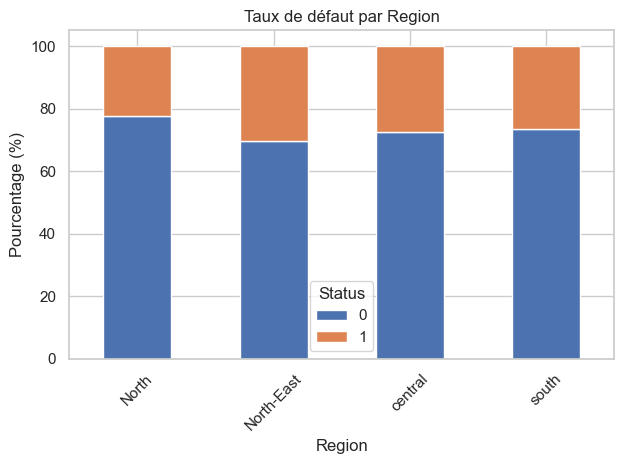

Status             0          1
loan_type                      
type1      77.225133  22.774867
type2      65.456122  34.543878
type3      74.944011  25.055989


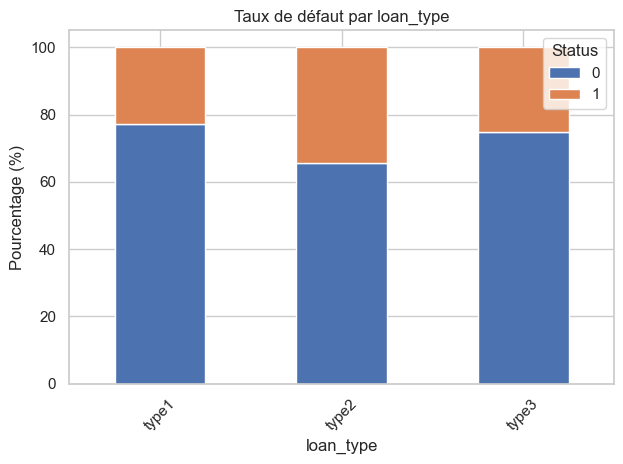

In [14]:
for col in ['Credit_Worthiness', 'business_or_commercial', 'Region','loan_type']:
    tab = pd.crosstab(df[col], df['Status'], normalize='index') * 100
    print(tab)
    tab.plot(kind='bar', stacked=True)
    plt.title(f'Taux de défaut par {col}')
    plt.ylabel('Pourcentage (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Conclusion 
L'analyse des variables qualitatives montre des variations significatives du taux de défaut (Status = 1) selon les segments : il est nettement plus élevé dans la région North-East (30,45 %), pour les prêts de type2 (34,54 %), ainsi que pour les crédits de nature commerciale (b/c à 34,54 %) — on note d'ailleurs que type2 et b/c affichent le même taux, ce qui suggère un fort recouvrement entre ces deux variables. À l'inverse, les profils rattachés à la catégorie nob/c ou disposant d'un meilleur indicateur de solvabilité (l1) présentent un risque de défaut beaucoup plus faible. Ces fluctuations confirment que ces variables catégorielles possèdent un pouvoir prédictif nettement supérieur à celui des variables numériques, et qu'elles porteront donc l'essentiel de la performance du modèle.

# 3. PRÉ-PROCESSING

## 3.1 Split Train/Test
Séparation 80/20 avec `stratify=y` pour préserver l'équilibre des classes dans chaque fold.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Status'])
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,      
    random_state=42, 
    stratify=y  
)

In [16]:
X_train.shape

(118936, 33)

## 3.2 Traitement des Valeurs Manquantes
Imputation via classe CustomDataImputer avec stratégies par variable...
### Stratégie Générale
- **Variables catégorielles** : Imputation par mode (conditionnel ou global)
- **Variables numériques** : Imputation par médiane (conditionnelle par groupes)
- **Cascades** : `property_value` → `LTV` (recalcul par formule)

### Ordre Critique des Imputations
1. Variables indépendantes (age, loan_purpose)
2. Variables conditionnées (income après age)
3. Agrégés (dtir1 après income)
4. Dépendantes (LTV après property_value)

### Classe CustomDataImputer
- Implémentation d'une classe scikit-learn compatible avec `fit`/`transform` :
- Imputation sur X_train et X_test
- Vérification de l'imputation


In [41]:
#version finale
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class CustomDataImputer(BaseEstimator, TransformerMixin): 
    def __init__(self):
        # Initialisation des valeurs de secours globales
        self.mode_global_purpose = None
        self.valeur_secours_approv_in_adv = "nopre"
        self.rate_median_global = None
        self.spread_median_global = None
        self.property_median_global = None
        self.upfront_median_global = None
        self.income_median_global = None
        self.dtir1_median_global = None
        self.mode_age_train = None
        
        self.mode_global_loan_limit = None
        self.mode_global_term = None
        self.mode_global_neg_amm = None
        self.mode_global_submission = None
        
        # Initialisation des grilles de correspondances (dictionnaires)
        self.mode_par_nature = None
        self.map_medians_rate = None
        self.map_medians_spread = None
        self.map_medians_property = None
        self.map_medians_upfront = None
        self.map_medians_income = None
        self.map_medianes_dtir1 = None
        
        self.map_modes_loan_limit = None
        self.map_modes_term = None
        self.map_modes_neg_amm = None
        self.map_modes_submission = None
        
        # Initialisation des bornes de quartiles
        self.bins_montant = None
        self.bins_income = None

    def fit(self, X, y=None):
        X_temp = X.copy()
        
        # 1. Calcul des statistiques globales de secours
        self.mode_global_purpose = X_temp['loan_purpose'].mode()[0]
        self.rate_median_global = X_temp['rate_of_interest'].median()
        self.spread_median_global = X_temp['Interest_rate_spread'].median()
        self.property_median_global = X_temp['property_value'].median()
        self.upfront_median_global = X_temp['Upfront_charges'].median()
        self.income_median_global = X_temp['income'].median()
        self.dtir1_median_global = X_temp['dtir1'].median()
        self.mode_age_train = X_temp['age'].mode()[0]
        
        self.mode_global_loan_limit = X_temp['loan_limit'].mode()[0] if not X_temp['loan_limit'].dropna().empty else 'cf'
        self.mode_global_term = X_temp['term'].mode()[0]
        self.mode_global_neg_amm = X_temp['Neg_ammortization'].mode()[0]
        self.mode_global_submission = X_temp['submission_of_application'].mode()[0]
        
        # 2. Mode conditionnel de loan_purpose par nature du prêt
        self.mode_par_nature = (
            X_temp.dropna(subset=['loan_purpose'])
            .groupby('business_or_commercial')['loan_purpose']
            .apply(lambda s: s.mode()[0] if not s.mode().empty else self.mode_global_purpose)
            .to_dict()
        )
        
        # 3. Médianes simples de taux et spread par type de prêt
        self.map_medians_rate = X_temp.groupby('loan_type')['rate_of_interest'].median().to_dict()
        self.map_medians_spread = X_temp.groupby('loan_type')['Interest_rate_spread'].median().to_dict()
        
        # 4. Calcul des quartiles de loan_amount (bornes élargies)
        _, bins_amt = pd.qcut(X_temp['loan_amount'], q=4, labels=False, retbins=True, duplicates='drop')
        bins_amt[0], bins_amt[-1] = -np.inf, np.inf
        self.bins_montant = bins_amt
        X_temp['tranche_montant'] = pd.cut(X_temp['loan_amount'], bins=self.bins_montant, labels=False, include_lowest=True)
        
        # 5. Médianes croisées basées sur les tranches de montant
        self.map_medians_property = X_temp.groupby(['tranche_montant', 'loan_type'])['property_value'].median().to_dict()
        self.map_medians_upfront = X_temp.groupby(['tranche_montant', 'business_or_commercial'])['Upfront_charges'].median().to_dict()
        self.map_medians_income = X_temp.groupby(['age', 'tranche_montant', 'business_or_commercial'])['income'].median().to_dict()
        
        # 6. Calcul des quartiles de revenus et grille triple clé pour dtir1
        _, bins_inc = pd.qcut(X_temp['income'], q=4, labels=False, retbins=True, duplicates='drop')
        bins_inc[0], bins_inc[-1] = -np.inf, np.inf
        self.bins_income = bins_inc
        X_temp['tranche_income'] = pd.cut(X_temp['income'], bins=self.bins_income, labels=False, include_lowest=True)
        
        self.map_medianes_dtir1 = (
            X_temp.groupby(['tranche_income', 'business_or_commercial', 'Credit_Worthiness'])['dtir1']
            .median().to_dict()
        )
        
        # 7. Cartographie des modes conditionnels pour les variables catégorielles
        self.map_modes_loan_limit = (
            X_temp.groupby('loan_type')['loan_limit']
            .apply(lambda s: s.mode()[0] if not s.mode().empty else self.mode_global_loan_limit).to_dict()
        )
        self.map_modes_term = (
            X_temp.groupby('loan_type')['term']
            .apply(lambda s: s.mode()[0] if not s.mode().empty else self.mode_global_term).to_dict()
        )
        self.map_modes_neg_amm = (
            X_temp.groupby('loan_type')['Neg_ammortization']
            .apply(lambda s: s.mode()[0] if not s.mode().empty else self.mode_global_neg_amm).to_dict()
        )    
        self.map_modes_submission = (
            X_temp.groupby(['loan_type', 'Region'])['submission_of_application']
            .apply(lambda s: s.mode()[0] if not s.mode().empty else self.mode_global_submission).to_dict()
        )
        
        return self
         
    def transform(self, X):
        X_copy = X.copy()
        
        # 1. Cartographie des taux, spreads et buts de prêt
        valeurs_conditionnelles = X_copy['business_or_commercial'].map(self.mode_par_nature).fillna(self.mode_global_purpose)
        valeurs_rate = X_copy['loan_type'].map(self.map_medians_rate).fillna(self.rate_median_global)
        valeurs_spread = X_copy['loan_type'].map(self.map_medians_spread).fillna(self.spread_median_global)
        
        # 2. Application des tranches de montant (loan_amount)
        tranche = pd.cut(X_copy['loan_amount'], bins=self.bins_montant, labels=False, include_lowest=True)
        
        # Imputation Upfront_charges
        cles_upfront = list(zip(tranche, X_copy['business_or_commercial']))
        valeurs_upfront = pd.Series([self.map_medians_upfront.get(c, self.upfront_median_global) for c in cles_upfront], index=X_copy.index)
        X_copy['Upfront_charges'] = X_copy['Upfront_charges'].fillna(valeurs_upfront)
        
        # Imputation property_value
        cles_prop = list(zip(tranche, X_copy['loan_type']))
        valeurs_prop = pd.Series([self.map_medians_property.get(c, self.property_median_global) for c in cles_prop], index=X_copy.index)
        X_copy['property_value'] = X_copy['property_value'].fillna(valeurs_prop)
        
        # Imputation age
        X_copy['age'] = X_copy['age'].fillna(self.mode_age_train)
        
        # Imputation income
        cles_inc = list(zip(X_copy['age'], tranche, X_copy['business_or_commercial']))
        valeurs_income = pd.Series([self.map_medians_income.get(c, self.income_median_global) for c in cles_inc], index=X_copy.index)
        X_copy['income'] = X_copy['income'].fillna(valeurs_income)
        
        # 3. Application des tranches de revenus (income) pour imputer dtir1
        tranche_inc = pd.cut(X_copy['income'], bins=self.bins_income, labels=False, include_lowest=True)
        cles_dtir1 = list(zip(tranche_inc, X_copy['business_or_commercial'], X_copy['Credit_Worthiness']))
        valeurs_dtir1 = pd.Series([self.map_medianes_dtir1.get(c, self.dtir1_median_global) for c in cles_dtir1], index=X_copy.index)
        
        # 4. Remplissage final des variables numériques et calcul de LTV
        X_copy['dtir1'] = X_copy['dtir1'].fillna(valeurs_dtir1)
        X_copy['Interest_rate_spread'] = X_copy['Interest_rate_spread'].fillna(valeurs_spread)
        X_copy['loan_purpose'] = X_copy['loan_purpose'].fillna(valeurs_conditionnelles)
        X_copy['approv_in_adv'] = X_copy['approv_in_adv'].fillna(self.valeur_secours_approv_in_adv)
        X_copy['rate_of_interest'] = X_copy['rate_of_interest'].fillna(valeurs_rate)
        
        #ltv_calcule = (X_copy['loan_amount'] / X_copy['property_value']) * 100
       # X_copy['LTV'] = X_copy['LTV'].fillna(ltv_calcule)
        
        # 5. Remplissage des variables catégorielles par mode avec sécurité
        X_copy['loan_limit'] = X_copy['loan_limit'].fillna(X_copy['loan_type'].map(self.map_modes_loan_limit)).fillna(self.mode_global_loan_limit)
        X_copy['term'] = X_copy['term'].fillna(X_copy['loan_type'].map(self.map_modes_term)).fillna(self.mode_global_term)
        X_copy['Neg_ammortization'] = X_copy['Neg_ammortization'].fillna(X_copy['loan_type'].map(self.map_modes_neg_amm)).fillna(self.mode_global_neg_amm)

        cles_sub = list(zip(X_copy['loan_type'], X_copy['Region']))
        valeurs_sub = pd.Series([self.map_modes_submission.get(c, self.mode_global_submission) for c in cles_sub], index=X_copy.index)
        X_copy['submission_of_application'] = X_copy['submission_of_application'].fillna(valeurs_sub)
        
        return X_copy

    custom_imputer = CustomDataImputer()
    joblib.dump(custom_imputer, 'custom_data_imputer.pkl')
    print("L'imputer personnalisé a été sauvegardé avec succès sous 'custom_data_imputer.pkl' !")

L'imputer personnalisé a été sauvegardé avec succès sous 'custom_data_imputer.pkl' !


In [34]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np
imp = CustomDataImputer()
imp.fit(X_train)
X_train_imputed = imp.transform(X_train)
print(X_train_imputed[['loan_purpose', 'approv_in_adv', 'rate_of_interest','Interest_rate_spread','Upfront_charges','LTV','property_value','age','income','dtir1','loan_limit','term','Neg_ammortization','submission_of_application']].isnull().sum())

loan_purpose                     0
approv_in_adv                    0
rate_of_interest                 0
Interest_rate_spread             0
Upfront_charges                  0
LTV                          12001
property_value                   0
age                              0
income                           0
dtir1                            0
loan_limit                       0
term                             0
Neg_ammortization                0
submission_of_application        0
dtype: int64


In [35]:
X_test_imputed = imp.transform(X_test)
print(X_test_imputed.isnull().sum()) 

ID                              0
year                            0
loan_limit                      0
Gender                          0
approv_in_adv                   0
loan_type                       0
loan_purpose                    0
Credit_Worthiness               0
open_credit                     0
business_or_commercial          0
loan_amount                     0
rate_of_interest                0
Interest_rate_spread            0
Upfront_charges                 0
term                            0
Neg_ammortization               0
interest_only                   0
lump_sum_payment                0
property_value                  0
construction_type               0
occupancy_type                  0
Secured_by                      0
total_units                     0
income                          0
credit_type                     0
Credit_Score                    0
co-applicant_credit_type        0
age                             0
submission_of_application       0
LTV           

## 3.3 Encodage des Variables Catégorielles & Feature Selection

### Approche Retenue
**LabelEncoder** : Conversion des catégories en nombres (0, 1, 2...) sans fuite de données

**Avantages :**
- Simple et robuste
- Pas de dépendance à la target (contrairement à TargetEncoder)
- Compatible avec tous les modèles (arbres, linéaires, NN)

### Variables Encodées
20 variables catégorielles encodées de manière cohérente entre train/test



In [42]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import joblib

X_train_encoded = X_train_imputed.copy()
X_test_encoded = X_test_imputed.copy()



variables_cat = [
    'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 
    'Credit_Worthiness', 'open_credit', 'business_or_commercial', 
    'Neg_ammortization', 'interest_only', 'lump_sum_payment', 
    'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 
    'credit_type', 'co-applicant_credit_type', 'age',
    'submission_of_application', 'Region', 'Security_Type'
]

# Nettoyage préventif des colonnes inutiles avant l'encodage
cols_a_retirer = ['ID', 'year', 'Credit_Score', 'property_value', 'LTV']
X_train_encoded = X_train_encoded.drop(columns=[c for c in cols_a_retirer if c in X_train_encoded.columns])
X_test_encoded = X_test_encoded.drop(columns=[c for c in cols_a_retirer if c in X_test_encoded.columns])

# Utilisation de OrdinalEncoder 

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)


X_train_encoded[variables_cat] = encoder.fit_transform(X_train_encoded[variables_cat].astype(str))
X_test_encoded[variables_cat] = encoder.transform(X_test_encoded[variables_cat].astype(str))

X_train_final = X_train_encoded
X_test_final = X_test_encoded

print(f"Final - Train: {X_train_final.shape}, Test: {X_test_final.shape}")
print(f"Pas de NaN : {X_train_final.isnull().sum().sum()}")

joblib.dump(encoder, 'ordinal_encoder_final.pkl')
print("L'OrdinalEncoder a été sauvegardé avec succès sous 'ordinal_encoder_final.pkl' !")

Final - Train: (118936, 28), Test: (29734, 28)
Pas de NaN : 0
L'OrdinalEncoder a été sauvegardé avec succès sous 'ordinal_encoder_final.pkl' !


## 3.4 Configuration & sauvegarde du pipeline de data preprocessing

In [43]:
from sklearn.pipeline import Pipeline
import joblib

# 1. Charger vos deux fichiers .pkl existants
custom_imputer = joblib.load('custom_data_imputer.pkl')
ordinal_encoder = joblib.load('ordinal_encoder_final.pkl')

# 2. Créer le pipeline global ordonné
# (L'imputation s'exécute en premier, suivie de l'encodage)
pipeline_preprocessing = Pipeline(steps=[
    ('imputer', custom_imputer),
    ('encoder', ordinal_encoder)
])

# 3. Sauvegarder le pipeline complet dans un nouveau fichier .pkl
joblib.dump(pipeline_preprocessing, 'pipeline_preprocessing_global.pkl')

print("Le pipeline global a été assemblé et sauvegardé sous 'pipeline_preprocessing_global.pkl' !")

Le pipeline global a été assemblé et sauvegardé sous 'pipeline_preprocessing_global.pkl' !


# 4. MODÉLISATION

## 4.1 Stratégie
- **10 modèles** avec class_weight='balanced'
- **Données scaled** pour KNN, MLP, SVM, LR 
- **Données brutes** pour arbres 


### Remarque
En principe le scalling devrait être sur le data preprocessing mais il y a certains modèles insensibles à l'échelle

In [ ]:
#après suppression des varialbles provoquant overfitting
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC


# NETTOYAGE, PREPARATION ET NORMALISATION DES DONNEES

# Important : FEATURE SELECTION COMPLÉMENTAIRE
# En plus des colonnes supprimées en section 3.4 (ID, year, Credit_Score, property_value, LTV),
# j'ai éliminé ici les variables qui causaient du surapprentissage lors des tests préliminaires.
# Ces variables présentent des fuites de données ou une multicolinéarité excessive :
# - Interest_rate_spread & rate_of_interest : redondance élevée
# - Upfront_charges : corrélé aux caractéristiques du prêt (fuite)
# - business_or_commercial, Security_Type, construction_type : surapprentissage détecté

# Liste exhaustive des colonnes toxiques à supprimer (Fuites de données et Doublons)
cols_a_exclure = [
    'Interest_rate_spread', 
    'rate_of_interest', 
    'Upfront_charges', 
    'business_or_commercial', 
    'Security_Type', 
    'construction_type'
]

# Suppression sécurisée des colonnes si elles sont présentes dans les DataFrames
if hasattr(X_train_final, 'columns'):
    X_train_final = X_train_final.drop(columns=[c for c in cols_a_exclure if c in X_train_final.columns])
if hasattr(X_test_final, 'columns'):
    X_test_final = X_test_final.drop(columns=[c for c in cols_a_exclure if c in X_test_final.columns])

# Extraction des valeurs pures pour les algorithmes
X_train_brut = X_train_final.values if hasattr(X_train_final, 'columns') else X_train_final
X_test_brut = X_test_final.values if hasattr(X_test_final, 'columns') else X_test_final

# Génération des matrices standardisées (sur le périmètre de variables nettoyé)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_brut)
X_test_scaled = scaler.transform(X_test_brut)

# Définition de la liste complète des modèles
modeles = [
    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_split=10)),
    ('Random Forest', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, max_depth=10)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('AdaBoost', AdaBoostClassifier(n_estimators=70, random_state=42)),
    ('KNN (k=5)', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ('Naive Bayes', GaussianNB()),
    ('MLP', MLPClassifier(max_iter=150, random_state=42, early_stopping=True)),
    ('Ridge Classifier', LogisticRegression(penalty='l2', class_weight='balanced', max_iter=500, n_jobs=-1, random_state=42)),
    ('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1))
    #,('SVM', SVC(class_weight='balanced', probability=True, kernel='linear', random_state=42))
]

resultats = []
modeles_entraines = {}

# =========================================================================
# 2. BOUCLE D'ENTRAÎNEMENT FLUIDE ET HERMÉTIQUE
# =========================================================================

for nom, modele in modeles:
    # Aiguillage des matrices selon la nature de l'algorithme
    if nom in ['Logistic Regression', 'KNN (k=5)', 'MLP', 'Ridge Classifier', 'SVM']:
        X_train_loop = X_train_scaled.copy()
        X_test_loop = X_test_scaled.copy()
    else:
        X_train_loop = X_train_brut.copy()
        X_test_loop = X_test_brut.copy()
        
    # Apprentissage isolé du modèle
    modele.fit(X_train_loop, y_train)
    modeles_entraines[nom] = modele
    
    # Calcul des prédictions et des probabilités associées
    y_pred = modele.predict(X_test_loop)
    y_proba = modele.predict_proba(X_test_loop)[:, 1] if hasattr(modele, 'predict_proba') else None
    
    # Évaluation des scores de performance
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    
    # Enregistrement et journalisation
    resultats.append({'Modele': nom, 'Recall': recall, 'F1': f1, 'AUC': auc})
    print(f" {nom:<20} : Recall={recall:.3f}, F1={f1:.3f}, AUC={auc:.3f}")

 Decision Tree        : Recall=0.636, F1=0.668, AUC=0.825
 Random Forest        : Recall=0.668, F1=0.698, AUC=0.864
 Gradient Boosting    : Recall=0.546, F1=0.694, AUC=0.863
 AdaBoost             : Recall=0.457, F1=0.624, AUC=0.834
 KNN (k=5)            : Recall=0.511, F1=0.612, AUC=0.796
 Naive Bayes          : Recall=0.023, F1=0.044, AUC=0.599
 MLP                  : Recall=0.578, F1=0.711, AUC=0.875
 Ridge Classifier     : Recall=0.631, F1=0.486, AUC=0.718
 Logistic Regression  : Recall=0.631, F1=0.486, AUC=0.718


## 4.2 Métrique Principale
**AUC-ROC** : 

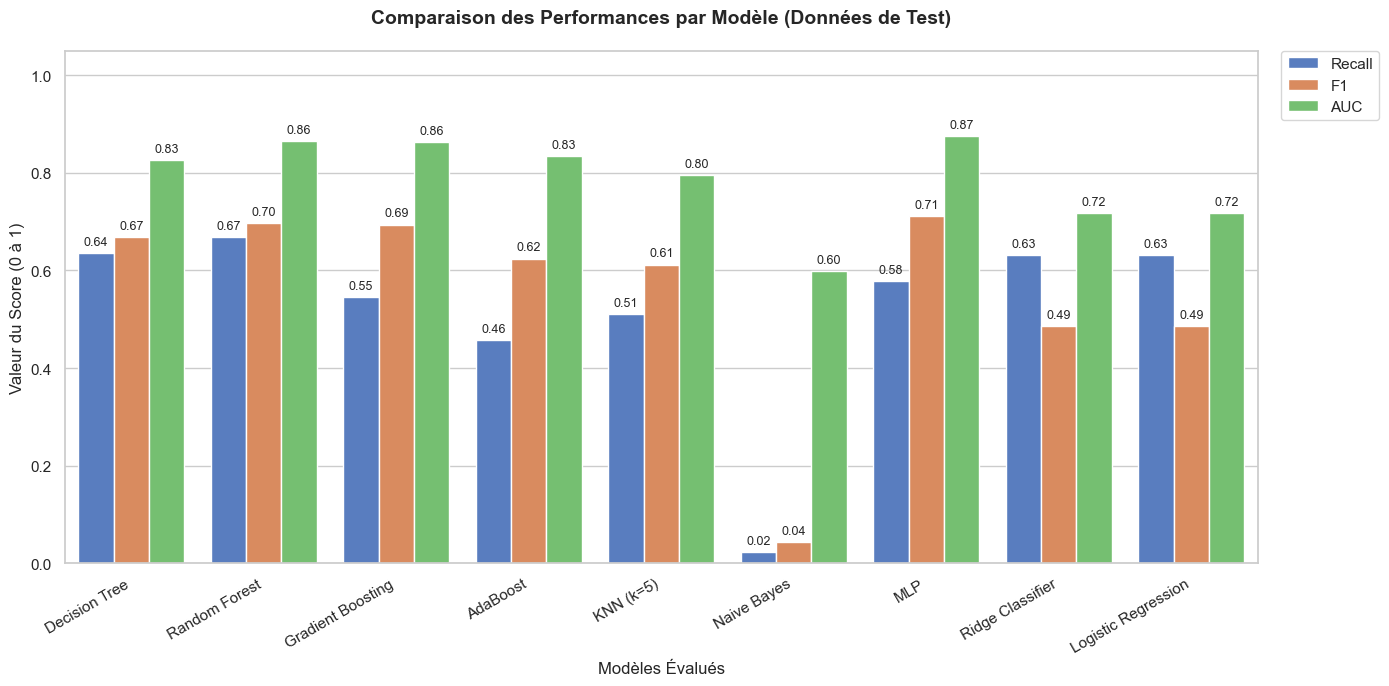

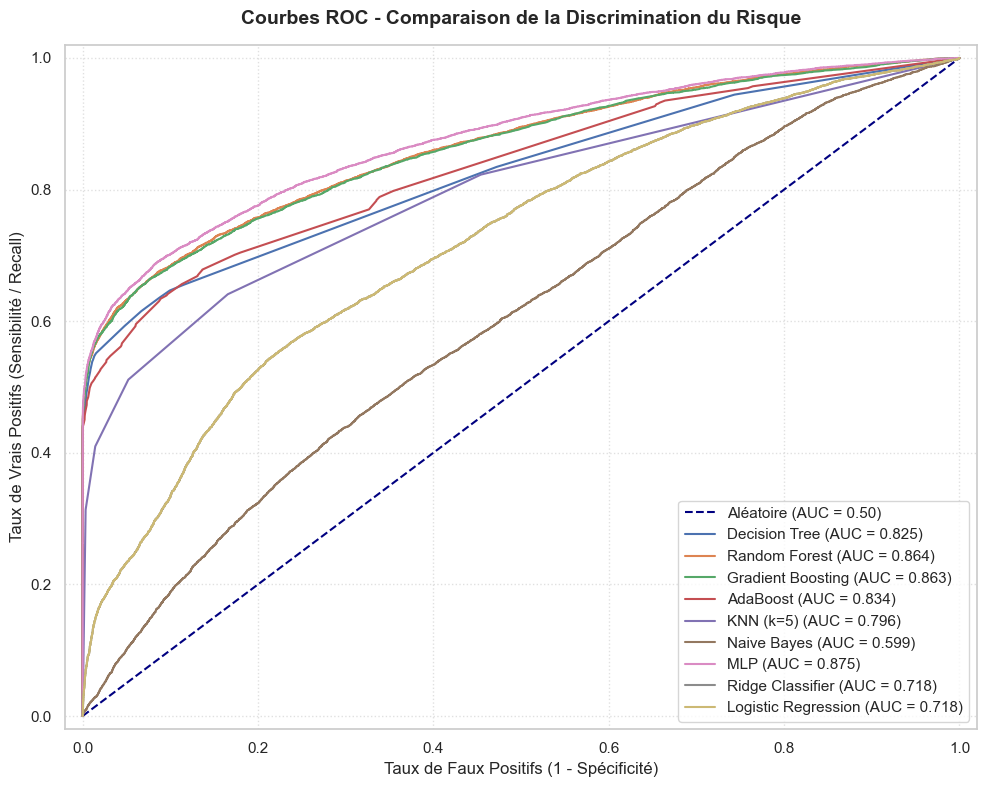

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# Configuration du style visuel
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Conversion des résultats récoltés en DataFrame
df_graphes = pd.DataFrame(resultats)

# =========================================================================
# GRAPHIC 1 : COMPARAISON GLOBALE DES MÉTRIQUES (BARPLOT)
# =========================================================================
# Pivotage des données pour adapter le format à Seaborn
df_melted = df_graphes.melt(id_vars="Modele", var_name="Metrique", value_name="Score")

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_melted, x="Modele", y="Score", hue="Metrique", palette="muted")

# Personnalisation des axes et titres
plt.title("Comparaison des Performances par Modèle (Données de Test)", pad=20, weight='bold')
plt.xlabel("Modèles Évalués")
plt.ylabel("Valeur du Score (0 à 1)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Affichage des valeurs textuelles au-dessus de chaque barre
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), 
                    textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

# =========================================================================
# GRAPHIC 2 : SUPERPOSITION DES COURBES ROC
# =========================================================================
plt.figure(figsize=(10, 8))

# Tracé de la ligne de référence aléatoire (diagonale)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Aléatoire (AUC = 0.50)')

# Génération des courbes ROC pour chaque modèle entraîné
for nom, modele in modeles_entraines.items():
    # Exclusion du Ridge Classifier s'il n'implémente pas predict_proba
    if hasattr(modele, 'predict_proba'):
        X_te = X_test_scaled if nom in ['Logistic Regression', 'KNN (k=5)', 'MLP', 'Ridge Classifier', 'SVM'] else X_test_brut
        y_proba = modele.predict_proba(X_te)[:, 1]
        
        # Calcul des taux de vrais positifs (tpr) et faux positifs (fpr)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = df_graphes.loc[df_graphes['Modele'] == nom, 'AUC'].values[0]
        
        plt.plot(fpr, tpr, label=f"{nom} (AUC = {auc_score:.3f})")

# Personnalisation graphique de la courbe ROC
plt.title("Courbes ROC - Comparaison de la Discrimination du Risque", pad=15, weight='bold')
plt.xlabel("Taux de Faux Positifs (1 - Spécificité)")
plt.ylabel("Taux de Vrais Positifs (Sensibilité / Recall)")
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 5. TUNING & OPTIMISATION

**Meilleur modèle initial** : MLP (0.875 AUC)

Tuning par GridSearchCV avec cross-validation 5-fold sur la métrique AUC.

In [46]:
# Liste exhaustive des colonnes toxiques à supprimer
cols_a_exclure = [
    'Interest_rate_spread', 
    'rate_of_interest', 
    'Upfront_charges', 
    'business_or_commercial', 
    'Security_Type', 
    'construction_type'
]

# 1. Nettoyage des colonnes si ce sont des DataFrames
if 'X_train_final' in locals() or 'X_train_final' in globals():
    if hasattr(X_train_final, 'columns'):
        X_train_final = X_train_final.drop(columns=[c for c in cols_a_exclure if c in X_train_final.columns])
if 'X_test_final' in locals() or 'X_test_final' in globals():
    if hasattr(X_test_final, 'columns'):
        X_test_final = X_test_final.drop(columns=[c for c in cols_a_exclure if c in X_test_final.columns])

# 2. Extraction des valeurs brutes sous forme de matrices NumPy pour X
X_train_brut = X_train_final.values if hasattr(X_train_final, 'columns') else X_train_final
X_test_brut = X_test_final.values if hasattr(X_test_final, 'columns') else X_test_final

# lignement par position et conversion en vecteur NumPy plat (1D array) pour y

if hasattr(y_train, 'iloc'):
    y_train = y_train.iloc[:X_train_brut.shape[0]].to_numpy().ravel()
else:
    y_train = np.array(y_train)[:X_train_brut.shape[0]].ravel()

if hasattr(y_test, 'iloc'):
    y_test = y_test.iloc[:X_test_brut.shape[0]].to_numpy().ravel()
else:
    y_test = np.array(y_test)[:X_test_brut.shape[0]].ravel()

# 4Génération des matrices standardisées pour X
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_brut)
X_test_scaled = scaler.transform(X_test_brut)

# Message de validation
print(f"Alignement et conversion NumPy validés !")
print(f"   -> Train : X = {X_train_brut.shape} | y = {y_train.shape}")
print(f"   -> Test  : X = {X_test_brut.shape}  | y = {y_test.shape}")

Alignement et conversion NumPy validés !
   -> Train : X = (118936, 22) | y = (118936,)
   -> Test  : X = (29734, 22)  | y = (29734,)


In [48]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV  
from sklearn.metrics import roc_auc_score
# =========================================================================
# 2. TUNING DES 3 MODÈLES SÉLECTIONNÉS (LR, RF, MLP)
# =========================================================================

# Définition des modèles de base (Avant Tuning)
modeles_avant = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, max_depth=10),
    'MLP': MLPClassifier(max_iter=150, random_state=42, early_stopping=True)
}

# Définition des grilles d'hyperparamètres pour le Tuning
grilles_parametres = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [5, 10],
        'min_samples_split': [5, 10]
    },
    'MLP': {
        'hidden_layer_sizes': [(50,), (50, 25)],
        'alpha': [0.0001, 0.01]
    }
}

tableau_comparatif = []

print(" Début de la phase de Tuning (Recherche par Grille)...")

for nom in modeles_avant.keys():
    print(f" Optimisation en cours pour : {nom}...")
    
    # Aiguillage des données (Scalées pour LR et MLP, Brutes pour le Random Forest)
    if nom in ['Logistic Regression', 'MLP']:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train_brut, X_test_brut
        
    # --- ÉVALUATION AVANT TUNING ---
    modele_defaut = modeles_avant[nom]
    modele_defaut.fit(X_tr, y_train)
    y_proba_av = modele_defaut.predict_proba(X_te)[:, 1] if hasattr(modele_defaut, 'predict_proba') else None
    auc_avant = roc_auc_score(y_test, y_proba_av) if y_proba_av is not None else np.nan
    
    # --- TUNING VIA GRIDSEARCHCV ---
    grid_search = GridSearchCV(
        estimator=modeles_avant[nom],
        param_grid=grilles_parametres[nom],
        scoring='roc_auc',
        cv=3,  # Validation croisée en 3 plis pour la rapidité
        n_jobs=-1
    )
    grid_search.fit(X_tr, y_train)
    
    # --- ÉVALUATION APRÈS TUNING ---
    meilleur_modele = grid_search.best_estimator_
    y_proba_ap = meilleur_modele.predict_proba(X_te)[:, 1] if hasattr(meilleur_modele, 'predict_proba') else None
    auc_apres = roc_auc_score(y_test, y_proba_ap) if y_proba_ap is not None else np.nan
    
    # Enregistrement des résultats dans le tableau
    tableau_comparatif.append({
        'Modèle': nom,
        'AUC Avant Tuning': round(auc_avant, 4),
        'AUC Après Tuning': round(auc_apres, 4),
        'Gain (AUC)': round(auc_apres - auc_avant, 4),
        'Meilleurs Paramètres': grid_search.best_params_
    })

# Affichage final du comparatif
df_comparatif = pd.DataFrame(tableau_comparatif)
print("\n --- TABLEAU COMPARATIF  ---")
print(df_comparatif.to_string(index=False))

 Début de la phase de Tuning (Recherche par Grille)...
 Optimisation en cours pour : Logistic Regression...
 Optimisation en cours pour : Random Forest...
 Optimisation en cours pour : MLP...

 --- TABLEAU COMPARATIF  ---
             Modèle  AUC Avant Tuning  AUC Après Tuning  Gain (AUC)                                            Meilleurs Paramètres
Logistic Regression            0.7179            0.7179      0.0000                                                       {'C': 10}
      Random Forest            0.8642            0.8656      0.0013 {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
                MLP            0.8750            0.8762      0.0012                    {'alpha': 0.01, 'hidden_layer_sizes': (50,)}


# 6. Sérialisation : Modèle en .pkl

In [49]:
# EXTRACTION ET SAUVEGARDE DU MODÈLE MLP ET DE SON SCALER


# je récupère le modèle MLP qui a été entraîné à l'intérieur de votre boucle
mlp_modele_entraine = modeles_entraines['MLP']

# création d'un dictionnaire qui rassemble le scaler et le modèle MLP
export_mlp = {
    'scaler': scaler,                  # Contient les règles de normalisation
    'model': mlp_modele_entraine       # Le réseau de neurones entraîné
}

# Sauvegarde dans un fichier unique .pkl
joblib.dump(export_mlp, 'modele_mlp_final.pkl')

print("Le modèle MLP et son Scaler ont été sauvegardés ensemble sous 'modele_mlp_final.pkl'")

Le modèle MLP et son Scaler ont été sauvegardés ensemble sous 'modele_mlp_final.pkl'
